In [ ]:
from google.colab import drive

drive.mount("/content/drive")

print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


In [ ]:
import os
import time
import torch
import torch.nn as nn
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import inception_v3, Inception_V3_Weights
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    precision_recall_fscore_support
)

# Device select pannrom
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

Device: cuda


In [ ]:
# Dataset paths set pannrom
BASE_DIR = "/content/drive/MyDrive/dataset/MILK10k_Split"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR = os.path.join(BASE_DIR, "val")
TEST_DIR = os.path.join(BASE_DIR, "test")

TRAIN_GT = os.path.join(TRAIN_DIR, "GroundTruth.csv")
VAL_GT = os.path.join(VAL_DIR, "GroundTruth.csv")
TEST_GT = os.path.join(TEST_DIR, "GroundTruth.csv")

TRAIN_IMG_DIR = os.path.join(TRAIN_DIR, "images")
VAL_IMG_DIR = os.path.join(VAL_DIR, "images")
TEST_IMG_DIR = os.path.join(TEST_DIR, "images")

print("Train directory exists :", os.path.exists(TRAIN_DIR))
print("Val directory exists   :", os.path.exists(VAL_DIR))
print("Test directory exists  :", os.path.exists(TEST_DIR))

print()
print("Train CSV exists :", os.path.exists(TRAIN_GT))
print("Val CSV exists   :", os.path.exists(VAL_GT))
print("Test CSV exists  :", os.path.exists(TEST_GT))

Train directory exists : True
Val directory exists   : True
Test directory exists  : True

Train CSV exists : True
Val CSV exists   : True
Test CSV exists  : True


In [ ]:
# Classes configure pannrom
CLASS_NAMES = [
    "melanoma",
    "nevus",
    "bcc",
    "scc",
    "keratoses"
]

cls2idx = {
    "melanoma": 0,
    "nevus": 1,
    "bcc": 2,
    "scc": 3,
    "keratoses": 4
}

NUM_CLASSES = 5

print("Classes:")
for i, name in enumerate(CLASS_NAMES):
    print(i, "->", name)

Classes:
0 -> melanoma
1 -> nevus
2 -> bcc
3 -> scc
4 -> keratoses


In [ ]:
# Image transform set pannrom
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Image transform created.")
print("Input size: 299 x 299")

Image transform created.
Input size: 299 x 299


In [ ]:
# Skin dataset class create pannrom
class SkinDataset(Dataset):
    def __init__(self, split_dir, transform=None):
        self.split_dir = split_dir
        self.transform = transform

        self.csv_path = os.path.join(split_dir, "GroundTruth.csv")
        self.metadata_path = os.path.join(split_dir, "Metadata.csv")
        self.image_dir = os.path.join(split_dir, "images")

        self.df = pd.read_csv(self.csv_path)
        self.metadata = pd.read_csv(self.metadata_path)

        self.samples = []

        print()
        print("CSV path      :", self.csv_path)
        print("Metadata path :", self.metadata_path)
        print("Image path    :", self.image_dir)
        print("Image folder exists :", os.path.exists(self.image_dir))

        print()
        print("GroundTruth columns:")
        print(self.df.columns.tolist())

        print()
        print("Metadata columns:")
        print(self.metadata.columns.tolist())

        image_files = []

        for root, dirs, files in os.walk(self.image_dir):
            for file in files:
                if file.lower().endswith((".jpg", ".jpeg", ".png")):
                    image_files.append(os.path.join(root, file))

        print()
        print("Image files found :", len(image_files))

        image_lookup = {}

        for image_path in image_files:
            filename = os.path.basename(image_path)
            isic_id = os.path.splitext(filename)[0]
            image_lookup[isic_id] = image_path

        metadata_lookup = {}

        for _, row in self.metadata.iterrows():
            lesion_id = str(row["lesion_id"])
            isic_id = str(row["isic_id"])

            if lesion_id not in metadata_lookup:
                metadata_lookup[lesion_id] = []

            metadata_lookup[lesion_id].append(isic_id)

        matched_count = 0

        for _, row in self.df.iterrows():
            lesion_id = str(row["lesion_id"])

            isic_ids = metadata_lookup.get(lesion_id, [])

            if row["MEL"] == 1:
                label = cls2idx["melanoma"]
            elif row["NV"] == 1:
                label = cls2idx["nevus"]
            elif row["BCC"] == 1:
                label = cls2idx["bcc"]
            elif row["SCCKA"] == 1:
                label = cls2idx["scc"]
            elif row["BKL"] == 1 or row["AKIEC"] == 1:
                label = cls2idx["keratoses"]
            else:
                continue

            for isic_id in isic_ids:
                image_path = image_lookup.get(isic_id)

                if image_path is not None:
                    self.samples.append((image_path, label))
                    matched_count += 1

        print()
        print(f"Matched images : {matched_count}")
        print(f"Loaded {len(self.samples)} images from {self.csv_path}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, label = self.samples[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# InceptionV3 ku image transforms set pannrom
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Transforms created successfully.")

Transforms created successfully.


In [ ]:
# Datasets create pannrom
train_dataset = SkinDataset(
    split_dir=TRAIN_DIR,
    transform=train_transform
)

val_dataset = SkinDataset(
    split_dir=VAL_DIR,
    transform=val_transform
)

test_dataset = SkinDataset(
    split_dir=TEST_DIR,
    transform=val_transform
)

print()
print("Datasets created")
print("Train images :", len(train_dataset))
print("Val images   :", len(val_dataset))
print("Test images  :", len(test_dataset))


CSV path      : /content/drive/MyDrive/dataset/MILK10k_Split/train/GroundTruth.csv
Metadata path : /content/drive/MyDrive/dataset/MILK10k_Split/train/Metadata.csv
Image path    : /content/drive/MyDrive/dataset/MILK10k_Split/train/images
Image folder exists : True

GroundTruth columns:
['lesion_id', 'AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']

Metadata columns:
['lesion_id', 'image_type', 'isic_id', 'attribution', 'copyright_license', 'image_manipulation', 'age_approx', 'sex', 'skin_tone_class', 'site', 'MONET_ulceration_crust', 'MONET_hair', 'MONET_vasculature_vessels', 'MONET_erythema', 'MONET_pigmented', 'MONET_gel_water_drop_fluid_dermoscopy_liquid', 'MONET_skin_markings_pen_ink_purple_pen']

Image files found : 8384

Matched images : 8076
Loaded 8076 images from /content/drive/MyDrive/dataset/MILK10k_Split/train/GroundTruth.csv

CSV path      : /content/drive/MyDrive/dataset/MILK10k_Split/val/GroundTruth.csv
Metadata path : /content/driv

In [ ]:
BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

In [ ]:
# Dataloader check pannrom
images, labels = next(iter(train_loader))

print("Image shape :", images.shape)
print("Label shape :", labels.shape)
print("Labels      :", labels[:10])

Image shape : torch.Size([16, 3, 299, 299])
Label shape : torch.Size([16])
Labels      : tensor([2, 2, 4, 2, 2, 4, 2, 0, 2, 2])


In [ ]:
# InceptionV3 model create pannrom
weights = Inception_V3_Weights.DEFAULT

model = inception_v3(
    weights=weights,
    aux_logits=True
)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

if model.AuxLogits is not None:
    model.AuxLogits.fc = nn.Linear(
        model.AuxLogits.fc.in_features,
        NUM_CLASSES
    )

model = model.to(DEVICE)

print("InceptionV3 model created")
print("Device      :", DEVICE)
print("Classes     :", NUM_CLASSES)
print("Input size  : 299 x 299")
print("Aux logits  : True")

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 167MB/s] 


INCEPTIONV3 MODEL CREATED
Device      : cuda
Classes     : 5
Input size  : 299 x 299
Aux logits  : True


In [ ]:
# Checkpoint paths set pannrom
CHECKPOINT_DIR = (
    "/content/drive/MyDrive/"
    "InceptionV3_MILK10k_Checkpoints"
)

LAST_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "last_checkpoint.pth"
)

BEST_CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "best_checkpoint.pth"
)

print("Checkpoint status")
print("Last checkpoint :", LAST_CHECKPOINT)
print("Last exists     :", os.path.exists(LAST_CHECKPOINT))
print("Best checkpoint :", BEST_CHECKPOINT)
print("Best exists     :", os.path.exists(BEST_CHECKPOINT))

CHECKPOINT STATUS
Last checkpoint : /content/drive/MyDrive/InceptionV3_MILK10k_Checkpoints/last_checkpoint.pth
Last exists     : True
Best checkpoint : /content/drive/MyDrive/InceptionV3_MILK10k_Checkpoints/best_checkpoint.pth
Best exists     : True


In [ ]:
# Last checkpoint load pannrom
checkpoint = torch.load(
    LAST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)

print("Checkpoint restored")
print("Last completed epoch :", checkpoint["epoch"])
print("Best Validation Macro-F1 :", checkpoint["best_f1"])

CHECKPOINT RESTORED
Last completed epoch : 100
Best Validation Macro-F1 : 0.6886283537170678


In [ ]:
# Loss function set pannrom
criterion = nn.CrossEntropyLoss()

print("Criterion:", criterion)

Criterion: CrossEntropyLoss()


In [ ]:
# Optimizer and AMP scaler set pannrom
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0001
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=torch.cuda.is_available()
)

print("Optimizer:", optimizer)
print("AMP scaler created.")

Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.01
)
AMP scaler created.


In [ ]:
# Resume settings set pannrom
start_epoch = checkpoint["epoch"]

EPOCHS = 100

best_f1 = checkpoint["best_f1"]

history = checkpoint.get(
    "history",
    []
)

print("Resume information")
print("Last completed epoch :", start_epoch)
print("Next epoch           :", start_epoch + 1)
print("Total epochs         :", EPOCHS)
print("Remaining epochs     :", EPOCHS - start_epoch)
print("Best Val Macro-F1    :", best_f1)

RESUME INFORMATION
Last completed epoch : 58
Next epoch           : 59
Total epochs         : 100
Remaining epochs     : 42
Best Val Macro-F1    : 0.4946382705491817


In [ ]:
# Training function create pannrom
def train_one_epoch(epoch):
    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    total_images = len(train_loader.dataset)

    progress_bar = tqdm(
        train_loader,
        desc=f"Training Epoch {epoch + 1}/{EPOCHS}",
        unit="batch"
    )

    for images, labels in progress_bar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            enabled=torch.cuda.is_available()
        ):
            outputs = model(images)

            if hasattr(outputs, "logits"):
                logits = outputs.logits
                aux_logits = outputs.aux_logits

                main_loss = criterion(logits, labels)
                aux_loss = criterion(aux_logits, labels)

                loss = main_loss + 0.4 * aux_loss
            else:
                logits = outputs
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = images.size(0)

        running_loss += loss.item() * batch_size

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

        all_labels.extend(
            labels.detach().cpu().numpy()
        )

    epoch_loss = running_loss / total_images

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    balanced_accuracy = balanced_accuracy_score(
        all_labels,
        all_preds
    )

    macro_precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    precision_values, recall_values, f1_values, support_values = (
        precision_recall_fscore_support(
            all_labels,
            all_preds,
            labels=list(range(NUM_CLASSES)),
            zero_division=0
        )
    )

    per_class = {}

    for i, class_name in enumerate(CLASS_NAMES):
        per_class[class_name] = {
            "precision": precision_values[i],
            "recall": recall_values[i],
            "f1": f1_values[i],
            "support": int(support_values[i])
        }

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "per_class": per_class
    }

print("train_one_epoch() created successfully.")

train_one_epoch() created successfully.


In [ ]:
# Validation and evaluation function create pannrom
def evaluate(loader):
    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    total_images = len(loader.dataset)

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            with torch.autocast(
                device_type="cuda",
                enabled=torch.cuda.is_available()
            ):
                outputs = model(images)

                if hasattr(outputs, "logits"):
                    logits = outputs.logits
                else:
                    logits = outputs

                loss = criterion(logits, labels)

            batch_size = images.size(0)

            running_loss += loss.item() * batch_size

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    epoch_loss = running_loss / total_images

    accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    balanced_accuracy = balanced_accuracy_score(
        all_labels,
        all_preds
    )

    macro_precision = precision_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    macro_recall = recall_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        all_labels,
        all_preds,
        average="macro",
        zero_division=0
    )

    weighted_precision = precision_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_recall = recall_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    weighted_f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted",
        zero_division=0
    )

    precision_values, recall_values, f1_values, support_values = (
        precision_recall_fscore_support(
            all_labels,
            all_preds,
            labels=list(range(NUM_CLASSES)),
            zero_division=0
        )
    )

    per_class = {}

    for i, class_name in enumerate(CLASS_NAMES):
        per_class[class_name] = {
            "precision": precision_values[i],
            "recall": recall_values[i],
            "f1": f1_values[i],
            "support": int(support_values[i])
        }

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "per_class": per_class
    }

print("evaluate() created successfully.")

evaluate() created successfully.


In [ ]:
# Learning rate scheduler set pannrom
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3
)

print("Scheduler created:")
print(scheduler)

Scheduler created:


In [ ]:
# Final training setup check pannrom
print("InceptionV3 training setup")
print("Device              :", DEVICE)
print("Train batches       :", len(train_loader))
print("Validation batches  :", len(val_loader))
print("Test batches        :", len(test_loader))
print("Start epoch         :", start_epoch)
print("Next epoch          :", start_epoch + 1)
print("Total epochs        :", EPOCHS)
print("Best Val Macro-F1   :", best_f1)

print()

print("Model               : OK")
print("Criterion           : OK")
print("Optimizer           : OK")
print("Scaler              : OK")
print("Scheduler           : OK")
print("train_one_epoch()   : OK")
print("evaluate()          : OK")

print()

print(
    "Last checkpoint exists :",
    os.path.exists(LAST_CHECKPOINT)
)

print(
    "Best checkpoint exists :",
    os.path.exists(BEST_CHECKPOINT)
)

INCEPTIONV3 TRAINING SETUP
Device              : cuda
Train batches       : 505
Validation batches  : 63
Test batches        : 63


NameError: name 'start_epoch' is not defined

In [ ]:
# Resume training pannrom
for epoch in range(
    start_epoch,
    EPOCHS
):
    print()
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    start_time = time.time()

    # Training metrics calculate pannrom
    train_metrics = train_one_epoch(epoch)

    # Validation metrics calculate pannrom
    val_metrics = evaluate(val_loader)

    val_f1 = val_metrics["macro_f1"]

    epoch_time = time.time() - start_time

    # Training history update pannrom
    history.append({
        "epoch": epoch + 1,
        "train": train_metrics,
        "val": val_metrics,
        "time": epoch_time
    })

    print()
    print("TRAIN METRICS")

    print(
        f"Train Loss              : "
        f"{train_metrics['loss']:.4f}"
    )

    print(
        f"Train Accuracy          : "
        f"{train_metrics['accuracy']:.4f}"
    )

    print(
        f"Train Balanced Accuracy : "
        f"{train_metrics['balanced_accuracy']:.4f}"
    )

    print(
        f"Train Macro Precision   : "
        f"{train_metrics['macro_precision']:.4f}"
    )

    print(
        f"Train Macro Recall      : "
        f"{train_metrics['macro_recall']:.4f}"
    )

    print(
        f"Train Macro F1          : "
        f"{train_metrics['macro_f1']:.4f}"
    )

    print(
        f"Train Weighted Precision: "
        f"{train_metrics['weighted_precision']:.4f}"
    )

    print(
        f"Train Weighted Recall   : "
        f"{train_metrics['weighted_recall']:.4f}"
    )

    print(
        f"Train Weighted F1       : "
        f"{train_metrics['weighted_f1']:.4f}"
    )

    print()

    for class_name in CLASS_NAMES:
        m = train_metrics["per_class"][class_name]

        print(
            f"{class_name:<15} | "
            f"Precision: {m['precision']:.4f} | "
            f"Recall: {m['recall']:.4f} | "
            f"F1: {m['f1']:.4f} | "
            f"Support: {m['support']}"
        )

    print()
    print("VALIDATION METRICS")

    print(
        f"Validation Loss              : "
        f"{val_metrics['loss']:.4f}"
    )

    print(
        f"Validation Accuracy          : "
        f"{val_metrics['accuracy']:.4f}"
    )

    print(
        f"Validation Balanced Accuracy : "
        f"{val_metrics['balanced_accuracy']:.4f}"
    )

    print(
        f"Validation Macro Precision   : "
        f"{val_metrics['macro_precision']:.4f}"
    )

    print(
        f"Validation Macro Recall      : "
        f"{val_metrics['macro_recall']:.4f}"
    )

    print(
        f"Validation Macro F1          : "
        f"{val_metrics['macro_f1']:.4f}"
    )

    print(
        f"Validation Weighted Precision: "
        f"{val_metrics['weighted_precision']:.4f}"
    )

    print(
        f"Validation Weighted Recall   : "
        f"{val_metrics['weighted_recall']:.4f}"
    )

    print(
        f"Validation Weighted F1       : "
        f"{val_metrics['weighted_f1']:.4f}"
    )

    print()

    for class_name in CLASS_NAMES:
        m = val_metrics["per_class"][class_name]

        print(
            f"{class_name:<15} | "
            f"Precision: {m['precision']:.4f} | "
            f"Recall: {m['recall']:.4f} | "
            f"F1: {m['f1']:.4f} | "
            f"Support: {m['support']}"
        )

    # Best model check pannrom
    is_best = val_f1 > best_f1

    if is_best:
        best_f1 = val_f1

    # Last checkpoint save pannrom
    checkpoint = {
        "epoch": epoch + 1,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "best_f1": best_f1,
        "history": history,
        "class_names": CLASS_NAMES
    }

    torch.save(
        checkpoint,
        LAST_CHECKPOINT
    )

    # Best checkpoint save pannrom
    if is_best:
        torch.save(
            checkpoint,
            BEST_CHECKPOINT
        )

        print()
        print("New best model saved")
        print(
            f"Best Validation Macro-F1 : "
            f"{best_f1:.4f}"
        )

    # Learning rate update pannrom
    scheduler.step(val_f1)

    print()
    print(
        f"Epoch time: "
        f"{epoch_time / 60:.2f} minutes"
    )


Epoch 59/100


Training Epoch 59/100:   0%|          | 0/505 [00:00<?, ?batch/s]


TRAIN METRICS
----------------------------------------------------------------------
Train Loss              : 1.0888
Train Accuracy          : 0.6919
Train Balanced Accuracy : 0.5675
Train Macro Precision   : 0.6189
Train Macro Recall      : 0.5675
Train Macro F1          : 0.5826
Train Weighted Precision: 0.6722
Train Weighted Recall   : 0.6919
Train Weighted F1       : 0.6730

melanoma        | Precision: 0.5349 | Recall: 0.3781 | F1: 0.4430 | Support: 730
nevus           | Precision: 0.6478 | Recall: 0.7426 | F1: 0.6920 | Support: 1154
bcc             | Precision: 0.7580 | Recall: 0.8912 | F1: 0.8192 | Support: 4052
scc             | Precision: 0.6029 | Recall: 0.4821 | F1: 0.5358 | Support: 784
keratoses       | Precision: 0.5508 | Recall: 0.3437 | F1: 0.4233 | Support: 1356

VALIDATION METRICS
----------------------------------------------------------------------
Validation Loss              : 0.7332
Validation Accuracy          : 0.7291
Validation Balanced Accuracy : 0.5947
Val

Training Epoch 60/100:   0%|          | 0/505 [00:00<?, ?batch/s]


TRAIN METRICS
----------------------------------------------------------------------
Train Loss              : 0.9327
Train Accuracy          : 0.7340
Train Balanced Accuracy : 0.6215
Train Macro Precision   : 0.6670
Train Macro Recall      : 0.6215
Train Macro F1          : 0.6379
Train Weighted Precision: 0.7197
Train Weighted Recall   : 0.7340
Train Weighted F1       : 0.7215

melanoma        | Precision: 0.5779 | Recall: 0.4521 | F1: 0.5073 | Support: 730
nevus           | Precision: 0.6862 | Recall: 0.7600 | F1: 0.7212 | Support: 1154
bcc             | Precision: 0.8047 | Recall: 0.9129 | F1: 0.8554 | Support: 4052
scc             | Precision: 0.6620 | Recall: 0.5421 | F1: 0.5961 | Support: 784
keratoses       | Precision: 0.6043 | Recall: 0.4403 | F1: 0.5094 | Support: 1356

VALIDATION METRICS
----------------------------------------------------------------------
Validation Loss              : 0.7004
Validation Accuracy          : 0.7351
Validation Balanced Accuracy : 0.6228
Val

...


TRAIN METRICS
----------------------------------------------------------------------
Train Loss              : 0.0309
Train Accuracy          : 0.9955
Train Balanced Accuracy : 0.9949
Train Macro Precision   : 0.9947
Train Macro Recall      : 0.9949
Train Macro F1          : 0.9948
Train Weighted Precision: 0.9955
Train Weighted Recall   : 0.9955
Train Weighted F1       : 0.9955

melanoma        | Precision: 0.9932 | Recall: 0.9945 | F1: 0.9938 | Support: 730
nevus           | Precision: 0.9948 | Recall: 0.9965 | F1: 0.9957 | Support: 1154
bcc             | Precision: 0.9975 | Recall: 0.9968 | F1: 0.9972 | Support: 4052
scc             | Precision: 0.9974 | Recall: 0.9949 | F1: 0.9962 | Support: 784
keratoses       | Precision: 0.9904 | Recall: 0.9919 | F1: 0.9912 | Support: 1356

VALIDATION METRICS
----------------------------------------------------------------------
Validation Loss              : 1.2260
Validation Accuracy          : 0.7739
Validation Balanced Accuracy : 0.6576
Val

Training Epoch 99/100:   0%|          | 0/505 [00:00<?, ?batch/s]


TRAIN METRICS
----------------------------------------------------------------------
Train Loss              : 0.0294
Train Accuracy          : 0.9967
Train Balanced Accuracy : 0.9952
Train Macro Precision   : 0.9960
Train Macro Recall      : 0.9952
Train Macro F1          : 0.9956
Train Weighted Precision: 0.9967
Train Weighted Recall   : 0.9967
Train Weighted F1       : 0.9967

melanoma        | Precision: 0.9986 | Recall: 0.9877 | F1: 0.9931 | Support: 730
nevus           | Precision: 0.9922 | Recall: 0.9983 | F1: 0.9952 | Support: 1154
bcc             | Precision: 0.9985 | Recall: 0.9983 | F1: 0.9984 | Support: 4052
scc             | Precision: 0.9974 | Recall: 0.9962 | F1: 0.9968 | Support: 784
keratoses       | Precision: 0.9934 | Recall: 0.9956 | F1: 0.9945 | Support: 1356

VALIDATION METRICS
----------------------------------------------------------------------
Validation Loss              : 1.2113
Validation Accuracy          : 0.7699
Validation Balanced Accuracy : 0.6641
Val

Training Epoch 100/100:   0%|          | 0/505 [00:00<?, ?batch/s]


TRAIN METRICS
----------------------------------------------------------------------
Train Loss              : 0.0263
Train Accuracy          : 0.9965
Train Balanced Accuracy : 0.9964
Train Macro Precision   : 0.9959
Train Macro Recall      : 0.9964
Train Macro F1          : 0.9961
Train Weighted Precision: 0.9965
Train Weighted Recall   : 0.9965
Train Weighted F1       : 0.9965

melanoma        | Precision: 0.9973 | Recall: 0.9959 | F1: 0.9966 | Support: 730
nevus           | Precision: 0.9965 | Recall: 0.9983 | F1: 0.9974 | Support: 1154
bcc             | Precision: 0.9985 | Recall: 0.9965 | F1: 0.9975 | Support: 4052
scc             | Precision: 0.9974 | Recall: 0.9949 | F1: 0.9962 | Support: 784
keratoses       | Precision: 0.9897 | Recall: 0.9963 | F1: 0.9930 | Support: 1356

VALIDATION METRICS
----------------------------------------------------------------------
Validation Loss              : 1.1762
Validation Accuracy          : 0.7719
Validation Balanced Accuracy : 0.6608
Val

In [ ]:
# Best InceptionV3 model load pannrom
import os
import torch
import torch.nn as nn
from torchvision.models import inception_v3

NUM_CLASSES = 5

BEST_CHECKPOINT = (
    "/content/drive/MyDrive/"
    "InceptionV3_MILK10k_Checkpoints/"
    "best_checkpoint.pth"
)

print("Loading best InceptionV3 model")
print("Checkpoint :", BEST_CHECKPOINT)
print(
    "Exists     :",
    os.path.exists(BEST_CHECKPOINT)
)

# InceptionV3 model create pannrom
model = inception_v3(
    weights=None,
    aux_logits=True
)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

if model.AuxLogits is not None:
    model.AuxLogits.fc = nn.Linear(
        model.AuxLogits.fc.in_features,
        NUM_CLASSES
    )

model = model.to(DEVICE)

# Best checkpoint load pannrom
checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print()
print("Best InceptionV3 model loaded")
print("Checkpoint :", BEST_CHECKPOINT)
print("Epoch      :", checkpoint.get("epoch"))
print("Best F1    :", checkpoint.get("best_f1"))
print("Model      :", "InceptionV3")

LOADING BEST INCEPTIONV3 MODEL
Checkpoint : /content/drive/MyDrive/InceptionV3_MILK10k_Checkpoints/best_checkpoint.pth
Exists     : True


/usr/local/lib/python3.13/dist-packages/torchvision/models/inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(



BEST INCEPTIONV3 MODEL LOADED
Checkpoint : /content/drive/MyDrive/InceptionV3_MILK10k_Checkpoints/best_checkpoint.pth
Epoch      : 86
Best F1    : 0.6886283537170678
Model      : InceptionV3


In [ ]:
# InceptionV3 test evaluation pannrom
import numpy as np
import torch

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

model.eval()

all_predictions = []
all_labels = []

test_loss = 0.0
total_samples = 0

criterion = torch.nn.CrossEntropyLoss()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(images)

        if isinstance(outputs, tuple):
            outputs = outputs[0]

        loss = criterion(
            outputs,
            labels
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        batch_size = labels.size(0)

        test_loss += loss.item() * batch_size
        total_samples += batch_size

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

test_loss = test_loss / total_samples

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

balanced_accuracy = balanced_accuracy_score(
    all_labels,
    all_predictions
)

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted",
    zero_division=0
)

print()
print("InceptionV3 test results")
print(f"Test Loss               : {test_loss:.4f}")
print(f"Accuracy                : {accuracy:.4f}")
print(f"Balanced Accuracy       : {balanced_accuracy:.4f}")
print(f"Macro Precision         : {macro_precision:.4f}")
print(f"Macro Recall            : {macro_recall:.4f}")
print(f"Macro F1                : {macro_f1:.4f}")
print(f"Weighted Precision      : {weighted_precision:.4f}")
print(f"Weighted Recall         : {weighted_recall:.4f}")
print(f"Weighted F1             : {weighted_f1:.4f}")


PANDERM TEST RESULTS
Test Loss               : 1.6605
Accuracy                : 0.6928
Balanced Accuracy       : 0.5584
Macro Precision         : 0.6055
Macro Recall            : 0.5584
Macro F1                : 0.5724
Weighted Precision      : 0.6762
Weighted Recall         : 0.6928
Weighted F1             : 0.6777


In [ ]:
# Per-class test metrics calculate pannrom
report = classification_report(
    all_labels,
    all_predictions,
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
)

print("Classification report")
print(report)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    melanoma     0.4574    0.5119    0.4831        84
       nevus     0.7037    0.6477    0.6746       176
         bcc     0.7829    0.9129    0.8429       482
         scc     0.5833    0.3415    0.4308        82
   keratoses     0.5000    0.3779    0.4305       172

    accuracy                         0.6928       996
   macro avg     0.6055    0.5584    0.5724       996
weighted avg     0.6762    0.6928    0.6777       996



Confusion Matrix:
[[ 43  26   7   0   8]
 [ 32 114  17   2  11]
 [  6   5 440   6  25]
 [  1   2  30  28  21]
 [ 12  15  68  12  65]]


<Figure size 800x800 with 0 Axes>

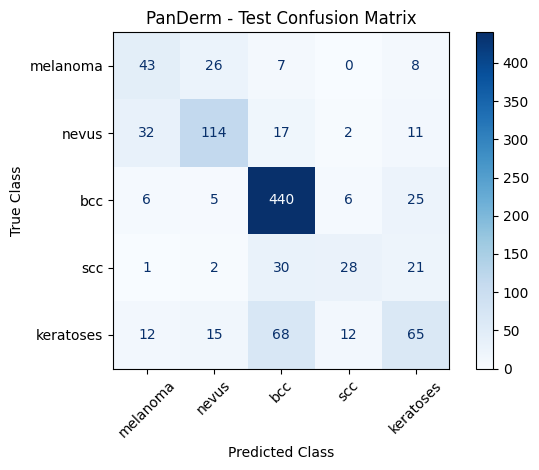

In [ ]:
# Confusion matrix create pannrom
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=CLASS_NAMES
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    "InceptionV3 - Test Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

<Figure size 800x800 with 0 Axes>

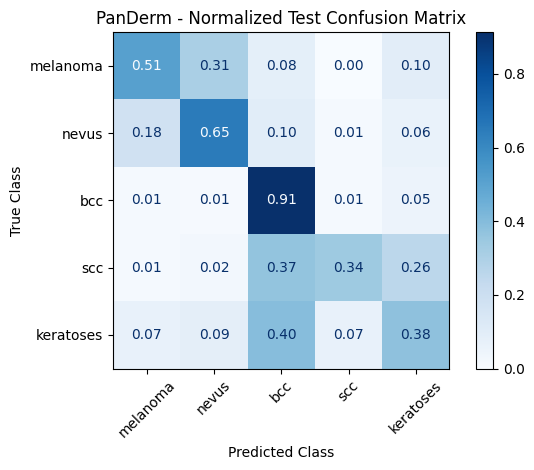

In [ ]:
# Normalized confusion matrix create pannrom
cm_normalized = confusion_matrix(
    all_labels,
    all_predictions,
    normalize="true"
)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=CLASS_NAMES
)

disp.plot(
    cmap="Blues",
    values_format=".2f"
)

plt.title(
    "InceptionV3 - Normalized Test Confusion Matrix"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
# Ovvoru class-kum oru test image select pannrom
class_images = {}

for index in range(len(test_dataset)):
    image_path, label = test_dataset.samples[index]
    class_name = CLASS_NAMES[label]

    if class_name not in class_images:
        class_images[class_name] = {
            "index": index,
            "path": image_path,
            "label": label
        }

    if len(class_images) == len(CLASS_NAMES):
        break

print("Test image selected for each class")

for class_name in CLASS_NAMES:
    item = class_images[class_name]

    print()
    print("Class :", class_name)
    print("Index :", item["index"])
    print("Path  :", item["path"])

TEST IMAGE SELECTED FOR EACH CLASS

Class : melanoma
Index : 22
Path  : /content/drive/MyDrive/dataset/MILK10k_Split/test/images/ISIC_3843458.jpg

Class : nevus
Index : 36
Path  : /content/drive/MyDrive/dataset/MILK10k_Split/test/images/ISIC_7960741.jpg

Class : bcc
Index : 2
Path  : /content/drive/MyDrive/dataset/MILK10k_Split/test/images/ISIC_8803389.jpg

Class : scc
Index : 0
Path  : /content/drive/MyDrive/dataset/MILK10k_Split/test/images/ISIC_5667730.jpg

Class : keratoses
Index : 12
Path  : /content/drive/MyDrive/dataset/MILK10k_Split/test/images/ISIC_6479651.jpg


Image: /content/drive/MyDrive/dataset/MILK10k_Split/test/images/ISIC_0887242.jpg
True Class: Keratoses

Prediction: Keratoses
Confidence: 52.77%


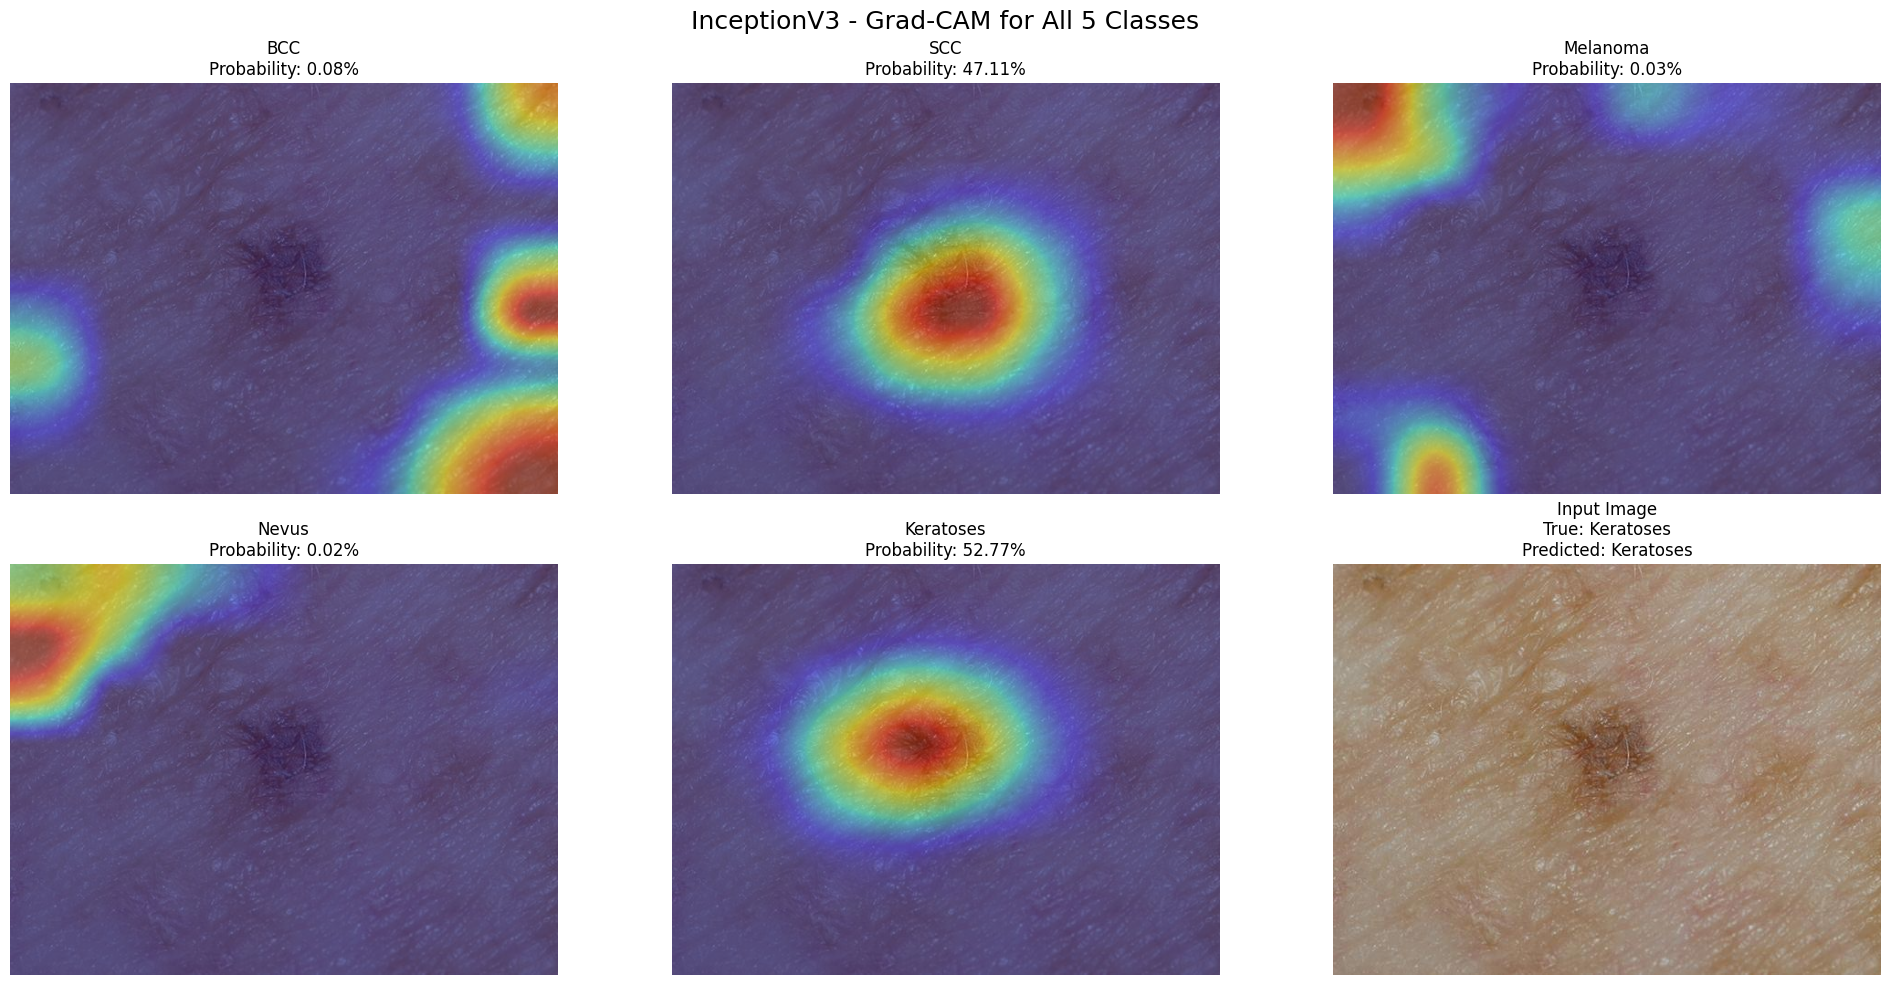

GRAD-CAM RESULTS - ALL 5 CLASSES
True Class     : Keratoses
Predicted Class: Keratoses
Confidence     : 0.5277
----------------------------------------------------------------------
BCC          : 0.0008
SCC          : 0.4711
Melanoma     : 0.0003
Nevus        : 0.0002
Keratoses    : 0.5277


In [ ]:
# InceptionV3 Grad-CAM for all 5 classes

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms

# Test image select pannrom
IMAGE_INDEX = 100

IMAGE_PATH = test_dataset.samples[IMAGE_INDEX][0]
TRUE_LABEL = test_dataset.samples[IMAGE_INDEX][1]

print("Image:", IMAGE_PATH)
print("True Class:", CLASS_NAMES[TRUE_LABEL])

# Model eval mode la set pannrom
model.eval()

# InceptionV3 target layer select pannrom
target_layer = model.Mixed_7c

# Image transform pannrom
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Original image load pannrom
original_image = Image.open(
    IMAGE_PATH
).convert("RGB")

image_tensor = transform(
    original_image
).unsqueeze(0).to(DEVICE)

# Activations and gradients store pannrom
activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)

# Forward pass pannrom
model.zero_grad()

output = model(image_tensor)

if hasattr(output, "logits"):
    logits = output.logits
elif isinstance(output, tuple):
    logits = output[0]
else:
    logits = output

# Prediction calculate pannrom
probabilities = torch.softmax(
    logits,
    dim=1
)

predicted_class = torch.argmax(
    probabilities,
    dim=1
).item()

predicted_confidence = probabilities[
    0,
    predicted_class
].item()

print("\nPrediction:", CLASS_NAMES[predicted_class])
print("Confidence:", f"{predicted_confidence:.2%}")

# All 5 classes-kum Grad-CAM create pannrom
cams = []

for class_index in range(NUM_CLASSES):
    model.zero_grad()
    gradients = None

    class_score = logits[
        0,
        class_index
    ]

    class_score.backward(
        retain_graph=True
    )

    activation = activations.detach()
    gradient = gradients.detach()

    weights = gradient.mean(
        dim=(2, 3),
        keepdim=True
    )

    cam = (
        weights * activation
    ).sum(dim=1)

    cam = torch.relu(cam)
    cam = cam.squeeze().cpu().numpy()

    if cam.max() > cam.min():
        cam = (
            cam - cam.min()
        ) / (
            cam.max() - cam.min()
        )
    else:
        cam = np.zeros_like(cam)

    cam_image = Image.fromarray(
        np.uint8(cam * 255)
    )

    cam_image = cam_image.resize(
        original_image.size
    )

    cam = np.array(
        cam_image
    ) / 255.0

    cams.append(cam)

# All 5 Grad-CAMs display pannrom
plt.figure(figsize=(20, 10))

for i in range(NUM_CLASSES):
    plt.subplot(2, 3, i + 1)

    plt.imshow(original_image)

    plt.imshow(
        cams[i],
        cmap="jet",
        alpha=0.45
    )

    class_name = CLASS_NAMES[i]

    class_probability = probabilities[
        0,
        i
    ].item()

    plt.title(
        f"{class_name}\n"
        f"Probability: {class_probability:.2%}"
    )

    plt.axis("off")

# Input image display pannrom
plt.subplot(2, 3, 6)

plt.imshow(original_image)

plt.title(
    f"Input Image\n"
    f"True: {CLASS_NAMES[TRUE_LABEL]}\n"
    f"Predicted: {CLASS_NAMES[predicted_class]}"
)

plt.axis("off")

plt.suptitle(
    "InceptionV3 - Grad-CAM for All 5 Classes",
    fontsize=18
)

plt.tight_layout()
plt.show()

# Grad-CAM results print pannrom
print("Grad-CAM Results - All 5 Classes")

print(
    "True Class     :",
    CLASS_NAMES[TRUE_LABEL]
)

print(
    "Predicted Class:",
    CLASS_NAMES[predicted_class]
)

print(
    "Confidence     :",
    f"{predicted_confidence:.4f}"
)

print("-" * 70)

for i in range(NUM_CLASSES):
    print(
        f"{CLASS_NAMES[i]:12s} : "
        f"{probabilities[0, i].item():.4f}"
    )

# Hooks remove pannrom
forward_handle.remove()
backward_handle.remove()